<a href="https://colab.research.google.com/github/paolopi81/projectile-motion-simulator/blob/main/projectile_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Insert the initial rate of the velocity (m). v0 =30
Insert launch angle (deg). alpha =45
Insert the mass of the bullet (kg). m =0.5
Insert the coefficient of viscous friction (kg*s^-1). C= 0.2


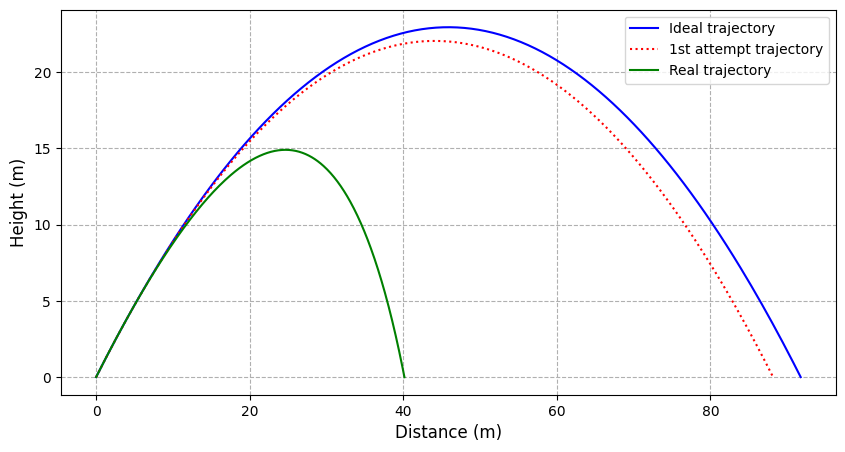

In [19]:

import numpy as np
import matplotlib.pyplot as plt
import sys

#DEFINING INITIAL CONDITIONS
g = 9.81 #m*s^-2
y0 = 0 #m
x0 = 0 #m

#TAKING USER INPUT
v0 = float(input("Insert the initial rate of the velocity (m). v0 ="))
alpha_deg = float(input("Insert launch angle (deg). alpha ="))
m = float(input("Insert the mass of the bullet (kg). m ="))
C = float(input("Insert the coefficient of viscous friction (kg*s^-1). C= "))

#CHECKING INPUTS
if alpha_deg == 90 or alpha_deg==0:
  print("Launch angle cannot be right or 0")
  sys.exit()
else:
  alpha = alpha_deg*np.pi/180 #rad
  v0x = v0*np.cos(alpha)
  v0y = v0*np.sin(alpha)

#TRAJECTORY OF THE IDEAL BULLET
ideal_Range = (2*v0x*v0y)/g
def ideal_trajectory(x, g, alpha, v0x):
  ideal_second_term = (g*x**2) / (2 * v0x**2)
  return x * np.tan(alpha) - ideal_second_term

#TRAJECTORY OF THE ATTEMPT BULLET
#ERROR IN THIS MODEL: We were, wrongly, supposing that the decrease in acceleration due to friction were constant,
#whereas it is proportional to velocity. Moreover, friction influences horizontal motion,too.
attempt_second_term = ((g+C/m)) / (2 * v0x**2)
attempt_Range = np.tan(alpha)/attempt_second_term
def attempt_trajectory(u, g, alpha, v0x):
  return u * np.tan(alpha) - attempt_second_term*u**2

#TRAJECTORY OF THE REAL BULLET
dt=0.01
vp = [v0x]
vq = [v0y]
p = [x0]
q = [y0]

while q[-1] >= 0:

  next_p=p[-1]+vp[-1]*dt
  next_q=q[-1]+vq[-1]*dt
  next_vp=vp[-1]-(C/m)*vp[-1]*dt
  next_vq=vq[-1]-(C/m)*vq[-1]*dt-g*dt

  p.append(next_p)
  q.append(next_q)
  vp.append(next_vp)
  vq.append(next_vq)


#CREATION OF THE COORDINATES
dx = np.linspace(0, ideal_Range, 200)
dy = ideal_trajectory(dx, g, alpha, v0x)
du = np.linspace(0, attempt_Range, 200)
dv = attempt_trajectory(du, g, alpha, v0x)


#PLOTTING THE TRAJECTORY
#NOTE ON VARIABLES: (u,v) and (p,q) still represent the standard (x,y) coordinates.
plt.figure(figsize=(10,5))
plt.plot(dx,dy, label="Ideal trajectory", color= "blue")
plt.plot(du, dv,label="1st attempt trajectory", color= "red", linestyle=':' )
plt.plot(p,q, label="Real trajectory", color = "green")
plt.xlabel("Distance (m)", fontsize=12)
plt.ylabel("Height (m)", fontsize=12)
plt.grid(True, linestyle='--')
plt.legend()
plt.show()
#TERMINAL VELOCITY: When C/m gets bigger, it is easier for friction to balance weight:
# the right branch of the trajectory flattens out and the projectile aproaches a terminal velocity.
